**04-eda-diabetes**

**1. CARGA DEL DATASET**

In [2]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle

In [3]:
# CARGO LOS DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
total_data = pd.read_csv(url)
total_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
total_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
total_data.shape

(768, 9)

In [7]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
total_data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

- El dataset contiene 768 filas y 9 columnas relacionadas con los datos de salud de varios pacientes.
- Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales.
- Incluye variables relacionnadas con los pacientes como su edad, niveles de glucosa, insulina, presión arterial, su índice de masa corporal y número de embarazos.
- El objetivo es predecir, con base en medidas diagnósticas, si un paciente tiene o no diabetes. Por lo tanto, 0 = no diabetes y 1 = diabetes.
- La variable 'outcome' será mi variable objetivo (target).

In [9]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [10]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [12]:
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

Index([], dtype='str')

- No se encontraron datos categóricos.

**2. LIMPIEZA INICIAL**

In [14]:
total_data.duplicated().sum()

np.int64(0)

In [15]:
total_data[total_data.duplicated() == True]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [16]:
total_data.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
6            148      72             35             0        33.6  0.627                     50   1          1
1            85       66             29             0        26.6  0.351                     31   0          1
8            183      64             0              0        23.3  0.672                     32   1          1
1            89       66             23             94       28.1  0.167                     21   0          1
0            137      40             35             168      43.1  2.288                     33   1          1
                                                                                                            ..
10           101      76             48             180      32.9  0.171                     63   0          1
2            122      70             27             0        36.8  0.340                     27   0          1
5     

In [17]:
total_data = total_data.drop_duplicates(keep="first")
print(total_data.shape)
total_data.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


- No se detectaron valores nulos, pero algunos valores tienen ceros que NO son reales (por ejemplo, no puedes tener 0 de glucosa y estar vivo).

In [18]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
for col in cols_with_zero:
    total_data[col] = total_data[col].replace(0, np.nan)

In [19]:
total_data = total_data.fillna(total_data.median())
total_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


**3. ANÁLISIS DE VARIABLES**

- Pregnancies: Número de embarazos del paciente (numérico)
- Glucose: Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure: Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness: Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin: Insulina sérica de 2 horas (medida en µU/ml) (numérico)
- BMI: Índice de masa corporal (numérico)
- DiabetesPedigreeFunction: Función de pedigrí de diabetes (numérico)
- Age: Edad del paciente (numérico)
- Outcome: Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1 positivo (numérico)

In [20]:
target = 'Outcome'

In [21]:
# Correlación con la variable objetivo
corr = total_data.corr()
corr_target = corr[target].sort_values(ascending=False)
corr_target

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

<Axes: xlabel='Outcome', ylabel='count'>

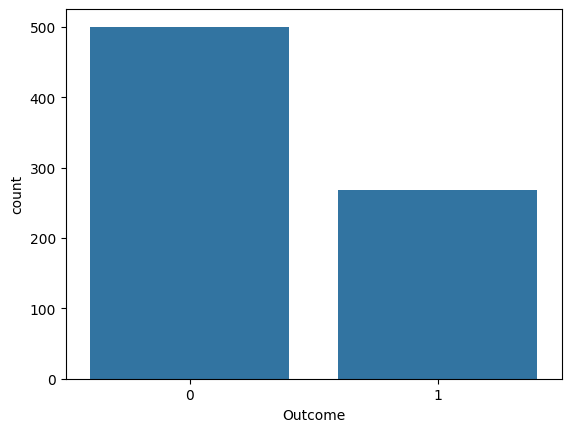

In [22]:
sns.countplot(x= target, data= total_data)

**4. RELACIONES ENTRE VARIABLES**

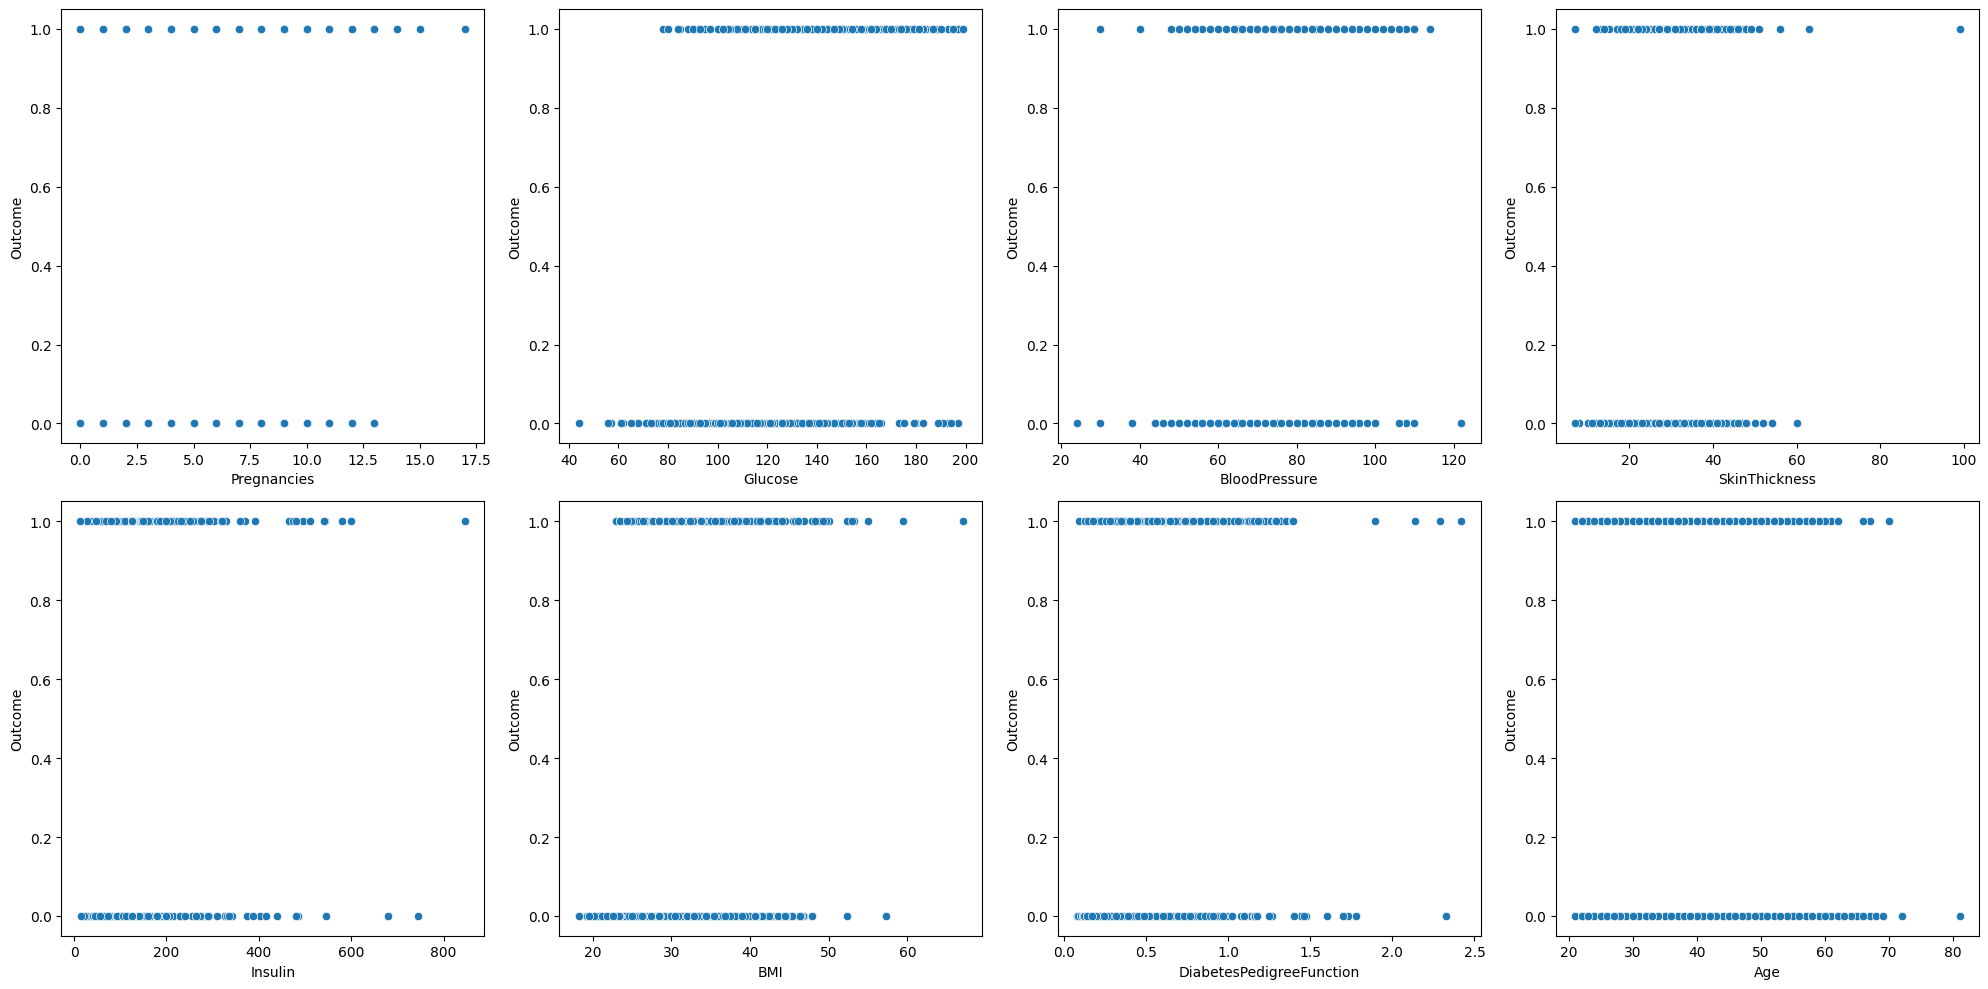

In [23]:
variables = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axis = plt.subplots(2, 4, figsize=(20, 10))
axis = axis.flatten()
for i, col in enumerate(variables):
    sns.scatterplot(data=total_data, x=col, y=target, ax=axis[i])
plt.tight_layout()
plt.show()

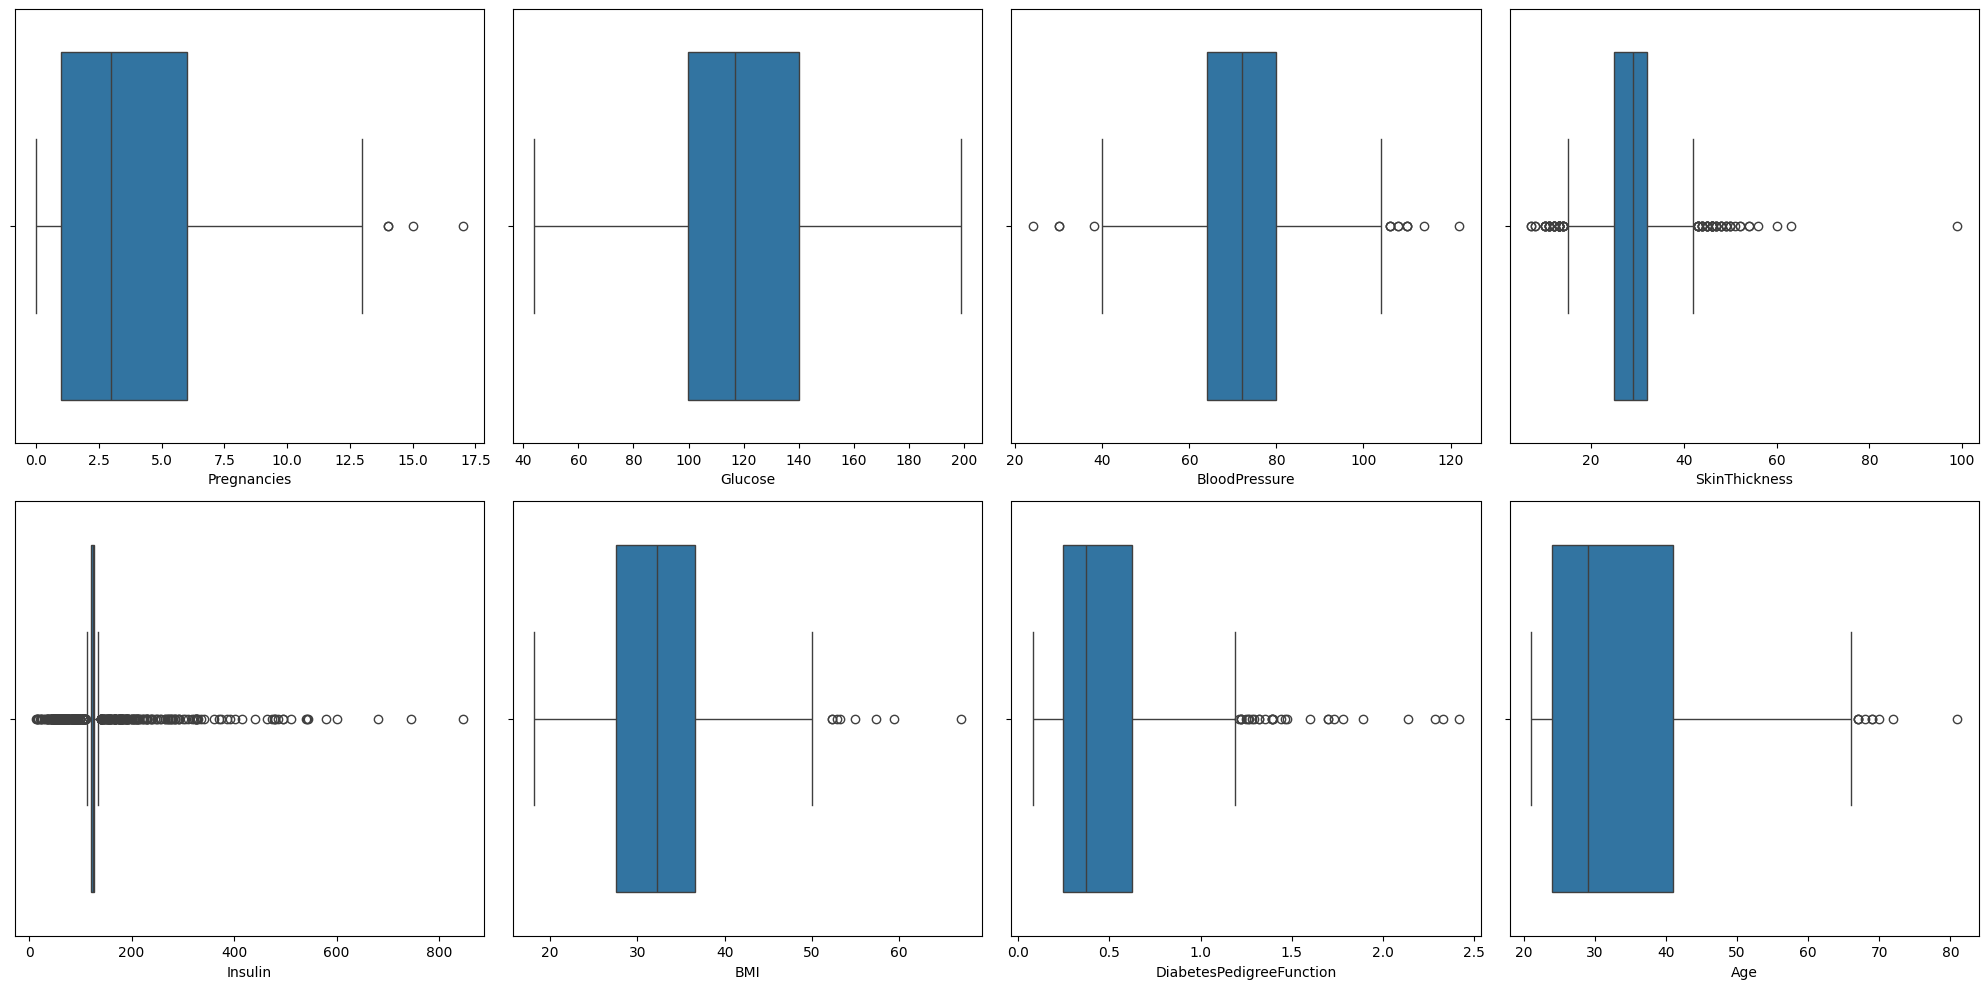

In [24]:
fig, axis = plt.subplots(2, 4, figsize=(20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["Pregnancies"])
sns.boxplot(ax = axis[0, 1], x = total_data["Glucose"])
sns.boxplot(ax = axis[0, 2], x = total_data["BloodPressure"])
sns.boxplot(ax = axis[0, 3], x = total_data["SkinThickness"])

sns.boxplot(ax = axis[1, 0], x = total_data["Insulin"])
sns.boxplot(ax = axis[1, 1], x = total_data["BMI"])
sns.boxplot(ax = axis[1, 2], x = total_data["DiabetesPedigreeFunction"])
sns.boxplot(ax = axis[1, 3], x = total_data["Age"])

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

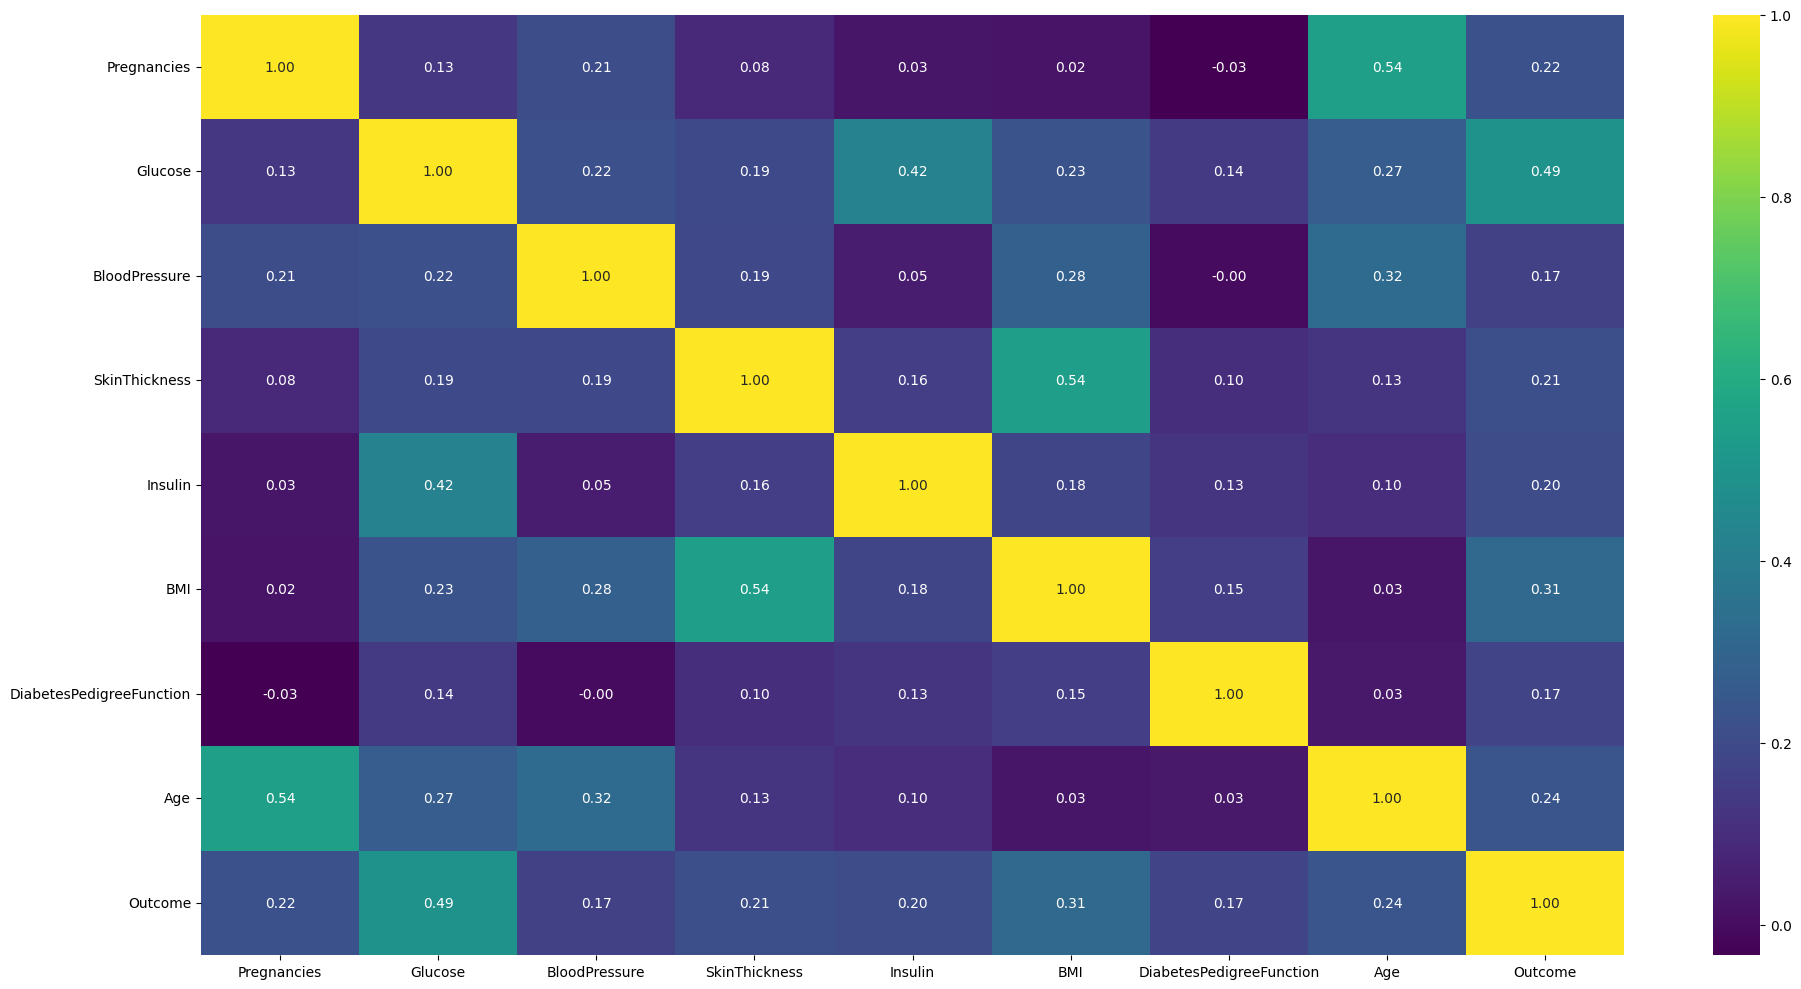

In [25]:
# Heatmap
selected = list(variables) + [target]

fig, ax= plt.subplots(figsize=(20, 10))
sns.heatmap(total_data[selected].corr(method="pearson"),
            annot=True, fmt=".2f", cmap="viridis", ax=ax)

plt.tight_layout()
plt.show

- La variable más correlacionada con la presencia de diabetes es la glucosa, lo que indica que es el factor que más influye para predecir la enfermedad, algo que también tiene sentido médico (glucosa alta = más riesgo de diabetes).
- Otras variables como el IMC, la edad o el número de embarazos muestran correlaciones moderadas, por lo que también aportan información relevante (a mayor edad, mayor riesgo y a más embarazos, hay algo más de riesgo).
- No hay correlaciones extremadamente altas entre las variables que justifiquen la eliminación de alguna de ellas. Además, como se utilizará un modelo de árbol de decisión, la multicolinealidad no será un problema.

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [26]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Outliers para la variable objetivo ('Outcome')**

In [27]:
# STATS OUTCOME
outcome_stats = total_data["Outcome"].describe()
outcome_stats

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Outcome, dtype: float64

In [28]:
# IQR OUTCOME
# RANGO INTERCUARTIL
outcome_iqr = outcome_stats["75%"] - outcome_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = outcome_stats["75%"] + 1.5 * outcome_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = outcome_stats["25%"] - 1.5 * outcome_iqr

print(f"IQR: {outcome_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 1.0
Upper limit: 2.5
Lower limit: -1.5


In [29]:
outliers_outcome = total_data[
    (total_data["Outcome"] >= upper_limit) | 
    (total_data["Outcome"] <= lower_limit)
]
print(f"Outliers en Outcome: {len(outliers_outcome)}")
outliers_outcome

Outliers en Outcome: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [ ]:
total_data[total_data["Outcome"] > 0]
# Resultado: 268 rows

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
755,1,128.0,88.0,39.0,110.0,36.5,1.057,37,1
757,0,123.0,72.0,29.0,125.0,36.3,0.258,52,1
759,6,190.0,92.0,29.0,125.0,35.5,0.278,66,1
761,9,170.0,74.0,31.0,125.0,44.0,0.403,43,1


- Esto significa que hay **268 diabéticos** (Outcome = 1).
- Como el dataset completo tiene 768 filas, 768 - 268 = **500 no diabéticos** (Outcome = 0).

**Outliers para 'Pregnancies'**

In [31]:
# STATS PREGNANCIES
pregnancies_stats = total_data["Pregnancies"].describe()
pregnancies_stats

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [32]:
# IQR PREGNANCIES
# RANGO INTERCUARTIL
pregnancies_iqr = pregnancies_stats["75%"] - pregnancies_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = pregnancies_stats["75%"] + 1.5 * pregnancies_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = pregnancies_stats["25%"] - 1.5 * pregnancies_iqr

print(f"IQR: {pregnancies_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 5.0
Upper limit: 13.5
Lower limit: -6.5


In [33]:
outliers_pregnancies = total_data[
    (total_data["Pregnancies"] >= upper_limit) | 
    (total_data["Pregnancies"] <= lower_limit)
]
print(f"Outliers en Pregnancies: {len(outliers_pregnancies)}")
outliers_pregnancies

Outliers en Pregnancies: 4


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1
298,14,100.0,78.0,25.0,184.0,36.6,0.412,46,1
455,14,175.0,62.0,30.0,125.0,33.6,0.212,38,1


**Outliers para 'Glucose'**

In [34]:
# STATS GLUCOSE
glucose_stats = total_data["Glucose"].describe()
glucose_stats

count    768.000000
mean     121.656250
std       30.438286
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [35]:
# IQR GLUCOSE
# RANGO INTERCUARTIL
glucose_iqr = glucose_stats["75%"] - glucose_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = glucose_stats["75%"] + 1.5 * glucose_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = glucose_stats["25%"] - 1.5 * glucose_iqr

print(f"IQR: {glucose_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 40.5
Upper limit: 201.0
Lower limit: 39.0


In [36]:
outliers_glucose = total_data[
    (total_data["Glucose"] >= upper_limit) | 
    (total_data["Glucose"] <= lower_limit)
]
print(f"Outliers en Glucose: {len(outliers_glucose)}")
outliers_glucose

Outliers en Glucose: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


**Outliers para 'BloodPressure'**

In [37]:
# STATS BLOOD PRESSURE
blood_stats = total_data["BloodPressure"].describe()
blood_stats

count    768.000000
mean      72.386719
std       12.096642
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [38]:
# IQR BLOOD PRESSURE
# RANGO INTERCUARTIL
blood_iqr = blood_stats["75%"] - blood_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = blood_stats["75%"] + 1.5 * blood_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = blood_stats["25%"] - 1.5 * blood_iqr

print(f"IQR: {blood_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 16.0
Upper limit: 104.0
Lower limit: 40.0


In [39]:
outliers_blood = total_data[
    (total_data["BloodPressure"] >= upper_limit) | 
    (total_data["BloodPressure"] <= lower_limit)
]
print(f"Outliers en BloodPressure: {len(outliers_blood)}")
outliers_blood

Outliers en BloodPressure: 17


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
18,1,103.0,30.0,38.0,83.0,43.3,0.183,33,0
43,9,171.0,110.0,24.0,240.0,45.4,0.721,54,1
84,5,137.0,108.0,29.0,125.0,48.8,0.227,37,1
106,1,96.0,122.0,29.0,125.0,22.4,0.207,27,0
125,1,88.0,30.0,42.0,99.0,55.0,0.496,26,1
177,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1
207,5,162.0,104.0,29.0,125.0,37.7,0.151,52,1
362,5,103.0,108.0,37.0,125.0,39.2,0.305,65,0
440,0,189.0,104.0,25.0,125.0,34.3,0.435,41,1


**Outliers para 'SkinThickness'**

In [40]:
# STATS SKIN THICKNESS
skin_stats = total_data["SkinThickness"].describe()
skin_stats

count    768.000000
mean      29.108073
std        8.791221
min        7.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

In [41]:
# IQR SKIN THICKNESS
# RANGO INTERCUARTIL
skin_iqr = skin_stats["75%"] - skin_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = skin_stats["75%"] + 1.5 * skin_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = skin_stats["25%"] - 1.5 * skin_iqr

print(f"IQR: {skin_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 7.0
Upper limit: 42.5
Lower limit: 14.5


In [42]:
outliers_skin = total_data[
    (total_data["SkinThickness"] >= upper_limit) | 
    (total_data["SkinThickness"] <= lower_limit)
]
print(f"Outliers en SkinThickness: {len(outliers_skin)}")
outliers_skin

Outliers en SkinThickness: 87


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
16,0,118.0,84.0,47.0,230.0,45.8,0.551,31,1
32,3,88.0,58.0,11.0,54.0,24.8,0.267,22,0
39,4,111.0,72.0,47.0,207.0,37.1,1.390,56,1
50,1,103.0,80.0,11.0,82.0,19.4,0.491,22,0
...,...,...,...,...,...,...,...,...,...
698,4,127.0,88.0,11.0,155.0,34.5,0.598,28,0
710,3,158.0,64.0,13.0,387.0,31.2,0.295,24,0
718,1,108.0,60.0,46.0,178.0,35.5,0.415,24,0
753,0,181.0,88.0,44.0,510.0,43.3,0.222,26,1


**Outliers para 'Insulin'**

In [43]:
# STATS INSULIN
insulin_stats = total_data["Insulin"].describe()
insulin_stats

count    768.000000
mean     140.671875
std       86.383060
min       14.000000
25%      121.500000
50%      125.000000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

In [44]:
# IQR INSULIN
# RANGO INTERCUARTIL
insulin_iqr = insulin_stats["75%"] - insulin_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = insulin_stats["75%"] + 1.5 * insulin_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = insulin_stats["25%"] - 1.5 * insulin_iqr

print(f"IQR: {insulin_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 5.75
Upper limit: 135.875
Lower limit: 112.875


In [45]:
outliers_insulin = total_data[
    (total_data["Insulin"] >= upper_limit) | 
    (total_data["Insulin"] <= lower_limit)
]
print(f"Outliers en Insulin: {len(outliers_insulin)}")
outliers_insulin

Outliers en Insulin: 346


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181.0,88.0,44.0,510.0,43.3,0.222,26,1
755,1,128.0,88.0,39.0,110.0,36.5,1.057,37,1
760,2,88.0,58.0,26.0,16.0,28.4,0.766,22,0
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0


**Outliers para 'BMI'**

In [46]:
# STATS BMI
bmi_stats = total_data["BMI"].describe()
bmi_stats

count    768.000000
mean      32.455208
std        6.875177
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [47]:
# IQR INSULIN
# RANGO INTERCUARTIL
bmi_iqr = bmi_stats["75%"] - bmi_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = bmi_stats["75%"] + 1.5 * bmi_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = bmi_stats["25%"] - 1.5 * bmi_iqr

print(f"IQR: {bmi_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 9.100000000000001
Upper limit: 50.25
Lower limit: 13.849999999999998


In [48]:
outliers_bmi = total_data[
    (total_data["BMI"] >= upper_limit) | 
    (total_data["BMI"] <= lower_limit)
]
print(f"Outliers en BMI: {len(outliers_bmi)}")
outliers_bmi

Outliers en BMI: 8


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
120,0,162.0,76.0,56.0,100.0,53.2,0.759,25,1
125,1,88.0,30.0,42.0,99.0,55.0,0.496,26,1
177,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1
193,11,135.0,72.0,29.0,125.0,52.3,0.578,40,1
247,0,165.0,90.0,33.0,680.0,52.3,0.427,23,0
303,5,115.0,98.0,29.0,125.0,52.9,0.209,28,1
445,0,180.0,78.0,63.0,14.0,59.4,2.420,25,1
673,3,123.0,100.0,35.0,240.0,57.3,0.880,22,0


**Outliers para 'DiabetesPedigreeFunction'**

In [49]:
# STATS DIABETES PEDIGREE FUNCTION
pedigree_stats = total_data["DiabetesPedigreeFunction"].describe()
pedigree_stats

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

In [50]:
# IQR DIABETES PEDIGREE FUNCTION
# RANGO INTERCUARTIL
pedigree_iqr = pedigree_stats["75%"] - pedigree_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = pedigree_stats["75%"] + 1.5 * pedigree_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = pedigree_stats["25%"] - 1.5 * pedigree_iqr

print(f"IQR: {pedigree_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 0.38249999999999995
Upper limit: 1.2
Lower limit: -0.32999999999999996


In [51]:
outliers_pedigree = total_data[
    (total_data["DiabetesPedigreeFunction"] >= upper_limit) | 
    (total_data["DiabetesPedigreeFunction"] <= lower_limit)
]
print(f"Outliers en DiabetesPedigreeFunction: {len(outliers_pedigree)}")
outliers_pedigree

Outliers en DiabetesPedigreeFunction: 29


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
12,10,139.0,80.0,29.0,125.0,27.1,1.441,57,0
39,4,111.0,72.0,47.0,207.0,37.1,1.390,56,1
45,0,180.0,66.0,39.0,125.0,42.0,1.893,25,1
58,0,146.0,82.0,29.0,125.0,40.5,1.781,44,0
100,1,163.0,72.0,29.0,125.0,39.0,1.222,33,1
147,2,106.0,64.0,35.0,119.0,30.5,1.400,34,0
187,1,128.0,98.0,41.0,58.0,32.0,1.321,33,1
218,5,85.0,74.0,22.0,125.0,29.0,1.224,32,1
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0


**Outliers para 'Age'**

In [52]:
# STATS AGE
age_stats = total_data["Age"].describe()
age_stats

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [53]:
# IQR AGE
# RANGO INTERCUARTIL
age_iqr = age_stats["75%"] - age_stats["25%"]
# LÍMITE SUPERIOR == Q3 + 1.5*IQR
upper_limit = age_stats["75%"] + 1.5 * age_iqr
# LÍMITE INFERIOR == Q1 + 1.5*IQR
lower_limit = age_stats["25%"] - 1.5 * age_iqr

print(f"IQR: {age_iqr}")
print(f"Upper limit: {upper_limit}")
print(f"Lower limit: {lower_limit}")

IQR: 17.0
Upper limit: 66.5
Lower limit: -1.5


In [54]:
outliers_age = total_data[
    (total_data["Age"] >= upper_limit) | 
    (total_data["Age"] <= lower_limit)
]
print(f"Outliers en Age: {len(outliers_age)}")
outliers_age

Outliers en Age: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
123,5,132.0,80.0,29.0,125.0,26.8,0.186,69,0
363,4,146.0,78.0,29.0,125.0,38.5,0.520,67,1
453,2,119.0,72.0,29.0,125.0,19.6,0.832,72,0
459,9,134.0,74.0,33.0,60.0,25.9,0.460,81,0
489,8,194.0,80.0,29.0,125.0,26.1,0.551,67,0
537,0,57.0,60.0,29.0,125.0,21.7,0.735,67,0
666,4,145.0,82.0,18.0,125.0,32.5,0.235,70,1
674,8,91.0,82.0,29.0,125.0,35.6,0.587,68,0
684,5,136.0,82.0,29.0,125.0,32.3,0.640,69,0


**El proyecto continúa en el notebook 04-decision-tree-diabetes.ipynb.**